In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
from snf import compute, make_affinity
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from lifelines import KaplanMeierFitter
import prince
import seaborn as sns

# Set a random seed for reproducibility
random_state = 492026

# Read in the data
df = pd.read_csv('../data/lung_cancer_data.csv')
df

,year_of_diagnosis,dx_lastcontact_death_months,puf_vital_status,puf_case_id,puf_facility_id,facility_type_cd,facility_location_cd,age,sex,race,...,mets_at_dx_liver,mets_at_dx_lung,mets_at_dx_other,tumor_size_summary_2016,rx_summ_surg_prim_site,rx_summ_treatment_status,rx_summ_chemo,rx_summ_immunotherapy,rx_summ_surgrad_seq,tumor_size_na
0,2018,1.120000,Dead,D00002e7d-bb34-46e6-849e-6c4f0acef147,RNYCFBVPLK,Community Cancer Program,South Atlantic,71,Male,White,...,NaN,Yes,Yes,94.0,NaN,No Treatment Given,NaN,NaN,No radiation therapy and/or surgical procedures,False
1,2019,34.070000,Dead,D00002f04-3dd7-4234-bb33-84f3a20b86c9,PSAHKJHEIG,Comprehensive Community Cancer Program,Pacific,Ninety or older,Female,Black,...,NaN,Yes,NaN,28.0,NaN,Treatment Given,NaN,"Immunotherapy recommended, unknown if administ...",No radiation therapy and/or surgical procedures,False
2,2019,21.450001,Dead,D0000690b-4418-4162-bc8e-2d62701c93ca,GQSMCSUAOK,Community Cancer Program,East North Central,80,Female,White,...,NaN,NaN,NaN,12.0,NaN,Treatment Given,Multiagent chemotherapy,NaN,No radiation therapy and/or surgical procedures,False
3,2022,1.380000,Dead,D00006b9c-dcb3-4535-a4fd-e20bd886fc9d,AUUCOIRDTB,Comprehensive Community Cancer Program,South Atlantic,80,Female,American Indian,...,NaN,NaN,Yes,87.0,NaN,Treatment Given,NaN,Immunotherapy administered as first course the...,No radiation therapy and/or surgical procedures,False
4,2019,40.049999,Alive,D00006dce-2eb8-498e-a6bc-da673b7a434e,CFHJPZWJNY,Integrated Network Cancer Program,West South Central,57,Female,White,...,NaN,NaN,NaN,NaN,NaN,Treatment Given,Multiagent chemotherapy,Immunotherapy administered as first course the...,No radiation therapy and/or surgical procedures,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501364,2020,7.360000,Dead,Dffff7a97-fd34-438d-b5b9-ca1930c78679,TXEIDOZHLI,Integrated Network Cancer Program,South Atlantic,75,Male,White,...,NaN,NaN,NaN,103.0,56.0,Treatment Given,Multiagent chemotherapy,Immunotherapy administered as first course the...,No radiation therapy and/or surgical procedures,False
501365,2018,12.160000,Dead,Dffff8d6c-a1cd-4085-9846-222b943a44d3,TVXWQGNICT,Comprehensive Community Cancer Program,Pacific,61,Female,White,...,NaN,NaN,NaN,46.0,NaN,Treatment Given,Multiagent chemotherapy,Immunotherapy administered as first course the...,No radiation therapy and/or surgical procedures,False
501366,2022,1.870000,Dead,Dffffabfc-6747-43e7-86c7-9cf043363c9f,UMUHJVXWPB,Integrated Network Cancer Program,West South Central,75,Male,Other,...,NaN,Yes,NaN,NaN,NaN,No Treatment Given,NaN,NaN,No radiation therapy and/or surgical procedures,True
501367,2018,38.410000,Alive,Dffffac4c-3b09-40a9-bfb0-45bd6333893d,JDTRSDGOHO,Community Cancer Program,West South Central,70,Male,White,...,Yes,NaN,NaN,32.0,12.0,Treatment Given,NaN,NaN,Radiation therapy after surgery,False


In [2]:
# Perform some cleaning
df['age'] = df['age'].replace('Ninety or older', 90).astype(float)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace('No Tumor found', 0)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace('1 mm or < 1 mm', 1)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace('>=989 mm', 989)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace('Site Specific Codes', np.nan)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace(
    'Microscopic focus/foci only/no size of focus', 0).astype(float)

# Impute missing values for 'tumor_size_summary_2016'
np.random.seed(random_state)
missing = df['tumor_size_summary_2016'].isna()
n_missing = missing.sum()
observed_values = df.loc[~missing, 'tumor_size_summary_2016']
imputed_values = np.random.choice(observed_values, size=n_missing, replace=True)
df.loc[missing, 'tumor_size_summary_2016'] = imputed_values

# Set any missing values in categorical columns to 'Unknown'
df['ur_cd_23'] = df['ur_cd_23'].fillna('Unknown')
df['mets_at_dx_bone'] = df['mets_at_dx_bone'].fillna('None')
df['mets_at_dx_brain'] = df['mets_at_dx_brain'].fillna('None')
df['mets_at_dx_distant_ln'] = df['mets_at_dx_distant_ln'].fillna('None')
df['mets_at_dx_liver'] = df['mets_at_dx_liver'].fillna('None')
df['mets_at_dx_lung'] = df['mets_at_dx_lung'].fillna('None')
df['mets_at_dx_other'] = df['mets_at_dx_other'].fillna('None')
df['rx_summ_surg_prim_site'] = df['rx_summ_surg_prim_site'].fillna('None')
df['rx_summ_chemo'] = df['rx_summ_chemo'].fillna('None')
df['rx_summ_immunotherapy'] = df['rx_summ_immunotherapy'].fillna('None')

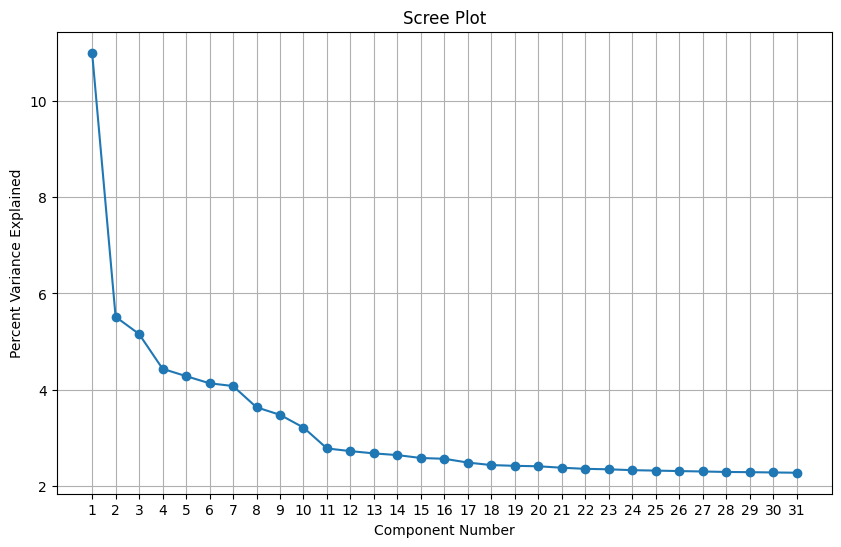

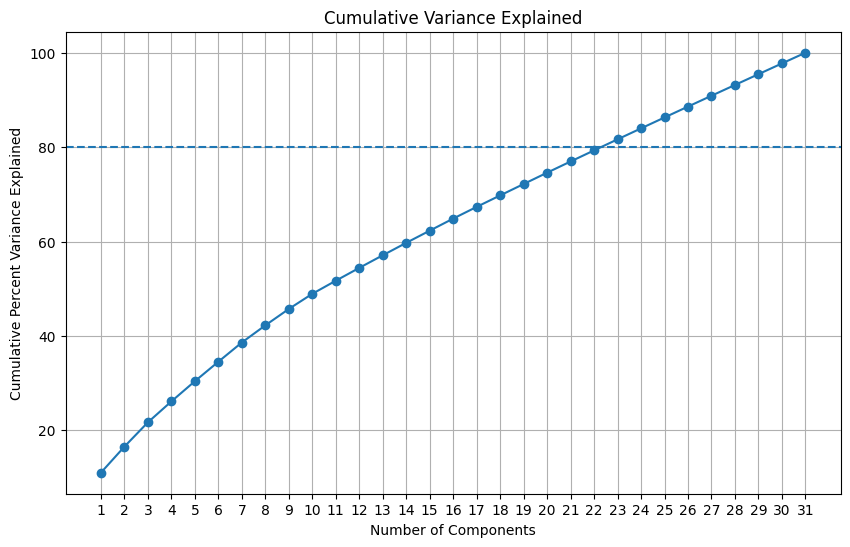

In [ ]:
# Perform Factor Analysis of Mixed Data (FAMD) to reduce dimensionality
X = df.drop(columns=['year_of_diagnosis', 'dx_lastcontact_death_months', 'puf_vital_status',
                     'puf_case_id', 'puf_facility_id', 'tobacco_use'])
famd = prince.FAMD(n_components=X.shape[1], random_state=random_state)
X_famd = famd.fit_transform(X)

# Calculate explained variance
eigenvalues = np.array(famd.eigenvalues_)
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Scree Plot (Individual Variance)
plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(explained_variance_ratio)+1),
    explained_variance_ratio * 100,
    marker='o'
)
plt.title('Scree Plot')
plt.xlabel('Component Number')
plt.ylabel('Percent Variance Explained')
plt.xticks(range(1, len(explained_variance_ratio)+1))
plt.grid(True)
plt.show()

# Cumulative Variance Plot
plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance * 100,
    marker='o'
)
plt.axhline(y=80, linestyle='--')
plt.title('Cumulative Variance Explained')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Percent Variance Explained')
plt.xticks(range(1, len(cumulative_variance)+1))
plt.grid(True)
plt.show()

In [8]:
X.shape

(501369, 31)

In [5]:
for col in df.columns:
    print(col)
    print(f"Number NA: {df[col].isna().sum()}")
    print(f"Percent NA: {df[col].isna().mean() * 100}%")
    print(df[col].value_counts(dropna=False))
    print("\n")

year_of_diagnosis
Number NA: 0
Percent NA: 0.0%
year_of_diagnosis
2019    106505
2018    103743
2022     98992
2021     98124
2020     94005
Name: count, dtype: int64


dx_lastcontact_death_months
Number NA: 0
Percent NA: 0.0%
dx_lastcontact_death_months
0.920000     1142
0.890000     1125
0.850000     1104
1.150000     1103
0.660000     1095
             ... 
87.889999       1
87.129997       1
87.389999       1
87.330002       1
87.849998       1
Name: count, Length: 2672, dtype: int64


puf_vital_status
Number NA: 0
Percent NA: 0.0%
puf_vital_status
Dead     272230
Alive    229139
Name: count, dtype: int64


puf_case_id
Number NA: 0
Percent NA: 0.0%
puf_case_id
D00002e7d-bb34-46e6-849e-6c4f0acef147    1
D00002f04-3dd7-4234-bb33-84f3a20b86c9    1
D0000690b-4418-4162-bc8e-2d62701c93ca    1
D00006b9c-dcb3-4535-a4fd-e20bd886fc9d    1
D00006dce-2eb8-498e-a6bc-da673b7a434e    1
                                        ..
Dffff7a97-fd34-438d-b5b9-ca1930c78679    1
Dffff8d6c-a1cd-4085-9846-2

In [3]:
df.columns

Index(['year_of_diagnosis', 'dx_lastcontact_death_months', 'puf_vital_status',
       'puf_case_id', 'puf_facility_id', 'facility_type_cd',
       'facility_location_cd', 'age', 'sex', 'race', 'spanish_hispanic_origin',
       'insurance_status', 'no_hsd_quar_2020', 'med_inc_quar_2020', 'ur_cd_23',
       'crowfly', 'cdcc_total_best', 'tobacco_use', 'primary_site',
       'laterality', 'histology', 'lymph_vascular_invasion',
       'regional_nodes_positive', 'analytic_stage_group', 'mets_at_dx_bone',
       'mets_at_dx_brain', 'mets_at_dx_distant_ln', 'mets_at_dx_liver',
       'mets_at_dx_lung', 'mets_at_dx_other', 'tumor_size_summary_2016',
       'rx_summ_surg_prim_site', 'rx_summ_treatment_status', 'rx_summ_chemo',
       'rx_summ_immunotherapy', 'rx_summ_surgrad_seq', 'tumor_size_na'],
      dtype='str')